In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import  LabelEncoder, StandardScaler
from pathlib import Path

path = "../df_encoded.csv"
df_encoded = pd.read_csv(path) #df = nome standardizzato per DataFrame

df_encoded.shape, df_encoded.head(), df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   participant_id                   500 non-null    int64  
 1   age                              500 non-null    int64  
 2   sleep_hours_previous_night       500 non-null    float64
 3   intervention_type                500 non-null    int64  
 4   intervention_duration_minutes    500 non-null    int64  
 5   productivity_rating              500 non-null    int64  
 6   mood_rating                      500 non-null    int64  
 7   side_effects                     500 non-null    int64  
 8   alertness_delta                  500 non-null    int64  
 9   occupation_Freelancer            500 non-null    bool   
 10  occupation_Student               500 non-null    bool   
 11  occupation_Working Professional  500 non-null    bool   
dtypes: bool(3), float64(1), int64(8)


((500, 12),
    participant_id  age  sleep_hours_previous_night  intervention_type  \
 0               1   24                         5.4                  1   
 1               2   37                         5.6                  1   
 2               3   32                         4.4                  0   
 3               4   28                         6.9                  0   
 4               5   25                         4.7                  1   
 
    intervention_duration_minutes  productivity_rating  mood_rating  \
 0                             15                    5           10   
 1                             30                    6            5   
 2                             30                    2            5   
 3                             30                    4            6   
 4                             30                    3            6   
 
    side_effects  alertness_delta  occupation_Freelancer  occupation_Student  \
 0             2               15 

Prima facciamo una analisi basata su PCA, poi proveremo tecniche di clustering.

In [2]:
df_y = df_encoded["side_effects"]
X = df_encoded.drop(["participant_id","side_effects"],axis=1)

In [3]:
X[["occupation_Freelancer","occupation_Student","occupation_Working Professional"]] = X[["occupation_Freelancer","occupation_Student","occupation_Working Professional"]].astype(int)

In [4]:
X.head()

,age,sleep_hours_previous_night,intervention_type,intervention_duration_minutes,productivity_rating,mood_rating,alertness_delta,occupation_Freelancer,occupation_Student,occupation_Working Professional
0,24,5.4,1,15,5,10,15,0,0,1
1,37,5.6,1,30,6,5,16,0,1,0
2,32,4.4,0,30,2,5,8,0,0,1
3,28,6.9,0,30,4,6,11,0,1,0
4,25,4.7,1,30,3,6,18,0,0,1


In [5]:
scaler = StandardScaler()

In [6]:
X_scaled = scaler.fit_transform(X)

In [7]:
X_scaled = pd.DataFrame(data = X_scaled, columns = X.columns)
X_scaled.head()

,age,sleep_hours_previous_night,intervention_type,intervention_duration_minutes,productivity_rating,mood_rating,alertness_delta,occupation_Freelancer,occupation_Student,occupation_Working Professional
0,-0.851162,-0.579904,1.045012,-1.292288,-0.131719,1.575447,0.228256,-0.651538,-0.782881,1.451065
1,0.745995,-0.403802,1.045012,1.363099,0.220470,-0.145225,0.426739,-0.651538,1.277333,-0.689149
2,0.131704,-1.460414,-0.956927,1.363099,-1.188284,-0.145225,-1.161128,-0.651538,-0.782881,1.451065
3,-0.359729,0.740861,-0.956927,1.363099,-0.483907,0.198910,-0.565678,-0.651538,1.277333,-0.689149
4,-0.728304,-1.196261,1.045012,1.363099,-0.836096,0.198910,0.823706,-0.651538,-0.782881,1.451065


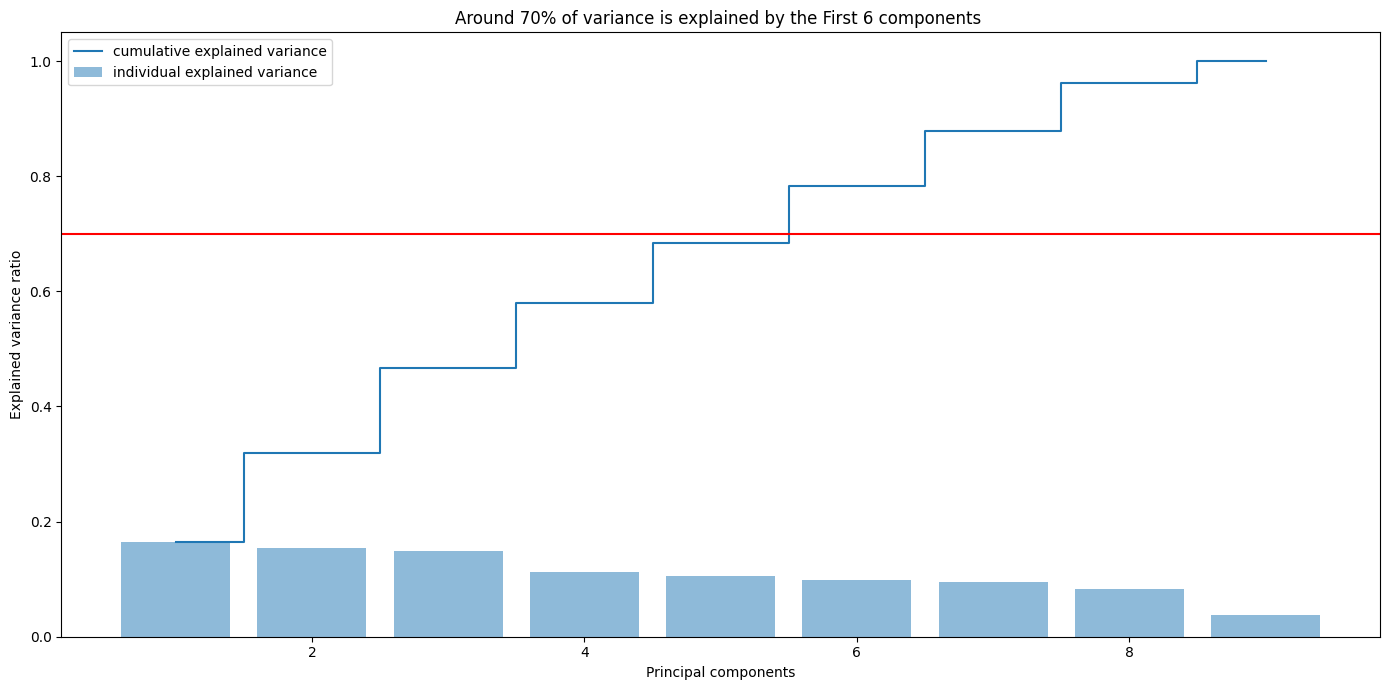

In [8]:
from sklearn.decomposition import PCA
ncomp = 9
pcan = PCA(n_components=ncomp)
pcan.fit(X_scaled.values)

plt.figure(1, figsize=(14, 7))
plt.bar(range(1,ncomp+1,1), pcan.explained_variance_ratio_, alpha=0.5, align='center',
        label='individual explained variance')
plt.step(range(1,ncomp+1,1),pcan.explained_variance_ratio_.cumsum(), where='mid',
         label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.title(f"Around 70% of variance is explained by the First {6} components ");
plt.legend(loc='best')
plt.axhline(y=0.7, color='r', linestyle='-') # 70% of  explained variance
plt.tight_layout()

Vediamo che le nostre feature hanno bisogno di 6 componenti principali perché almeno il 70 % della loro varianza sia spiegata. Proviamo comunque a visualizzare i dati con una proiezione 2D.

In [25]:
ncomp = 2
pcan = PCA(n_components=ncomp)
pc_df = pcan.fit_transform(X_scaled.values)
pc_df = pd.DataFrame(data = pc_df, columns = ["PC1","PC2"])


In [10]:
pc_df["target"] = df_y

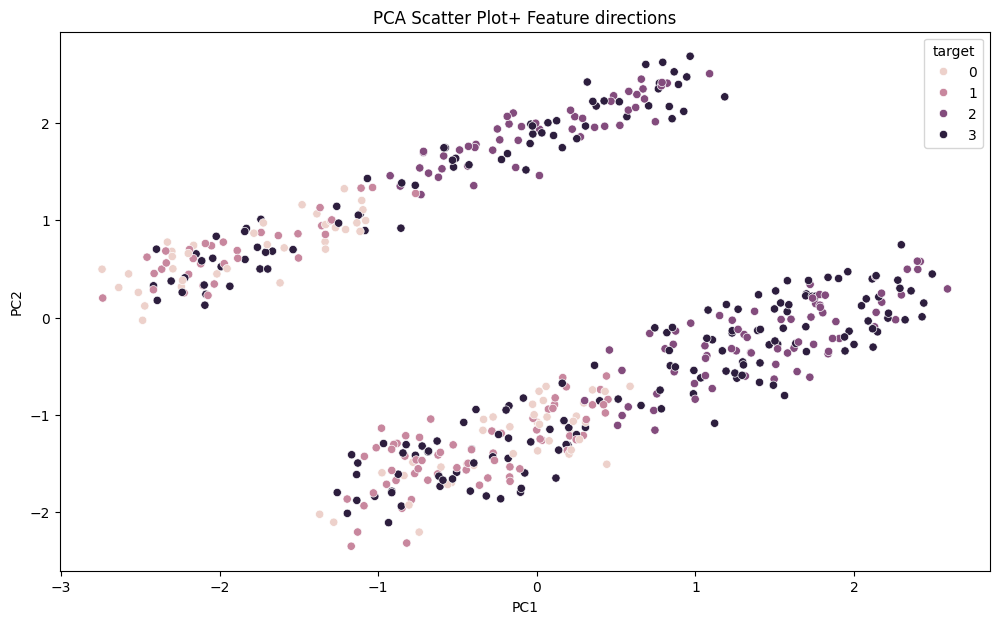

In [11]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=pc_df, x="PC1", y="PC2", hue="target" # Grouping data points with different colors
)

plt.title('PCA Scatter Plot+ Feature directions')
plt.show()

Qui il target sono i tipi di side-effects (il vero target dell'analisi). (0= No side effects, 1= grogginess, 2= crash, 3= anxiety)

Vediamo che sembrano comparire due cluster. (Qui il target sono i side-effects).

In [12]:
pc_df2 = pc_df
pc_df2.drop("target", axis=1, inplace=True)
pc_df2["target"] = (X_scaled["alertness_delta"]>0).astype(int)

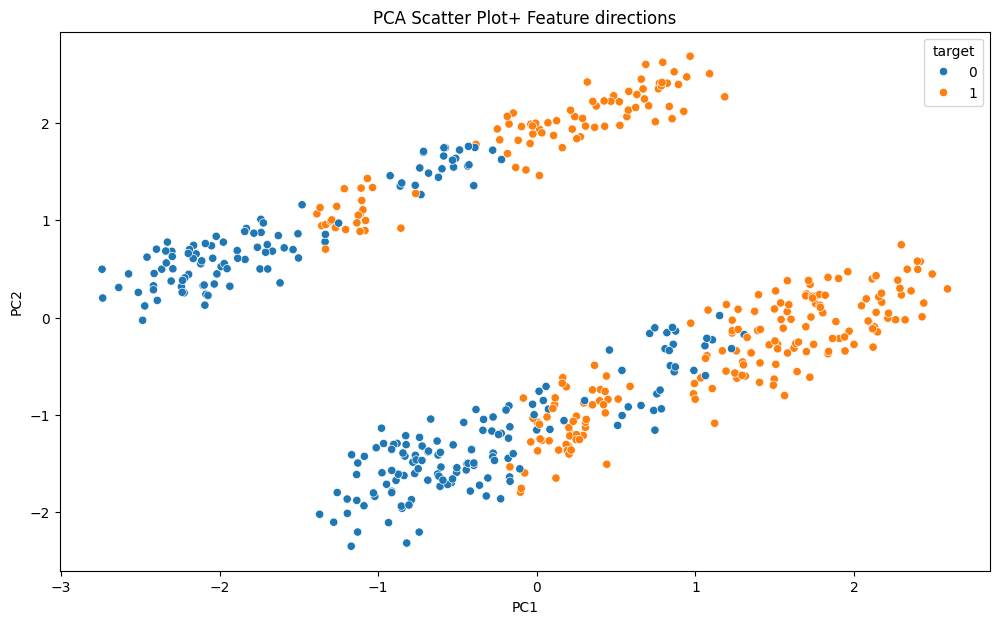

In [13]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=pc_df2, x="PC1", y="PC2", hue="target" # Grouping data points with different colors
)

plt.title('PCA Scatter Plot+ Feature directions')
plt.show()

Qui il target è se l'alertness delta è >0 o no.
Dunque, i due cluster non sono semplicemente dovuti a se l'alertness delta è >0 o no.

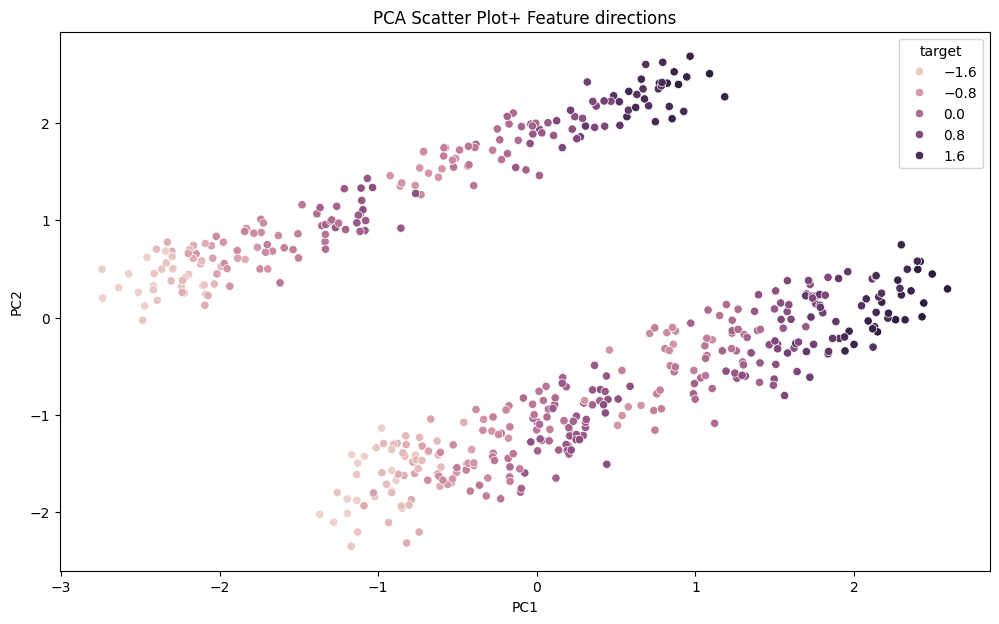

In [14]:
pc_df2 = pc_df
pc_df2.drop("target", axis=1, inplace=True)
pc_df2["target"] = X_scaled["alertness_delta"]
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=pc_df2, x="PC1", y="PC2", hue="target" # Grouping data points with different colors
)

plt.title('PCA Scatter Plot+ Feature directions')
plt.show()

Target: alertness delta numerico.
Da questo plot, sembra che la direzione ascendente dei due cluster sia associata al delta alertness. Proviamo a tracciare effettivamente le proiezioni delle direzioni associate alle features.

In [15]:
feature_names = X_scaled.columns[:-1]
feature_names

Index(['age', 'sleep_hours_previous_night', 'intervention_type',
       'intervention_duration_minutes', 'productivity_rating', 'mood_rating',
       'alertness_delta', 'occupation_Freelancer', 'occupation_Student'],
      dtype='str')

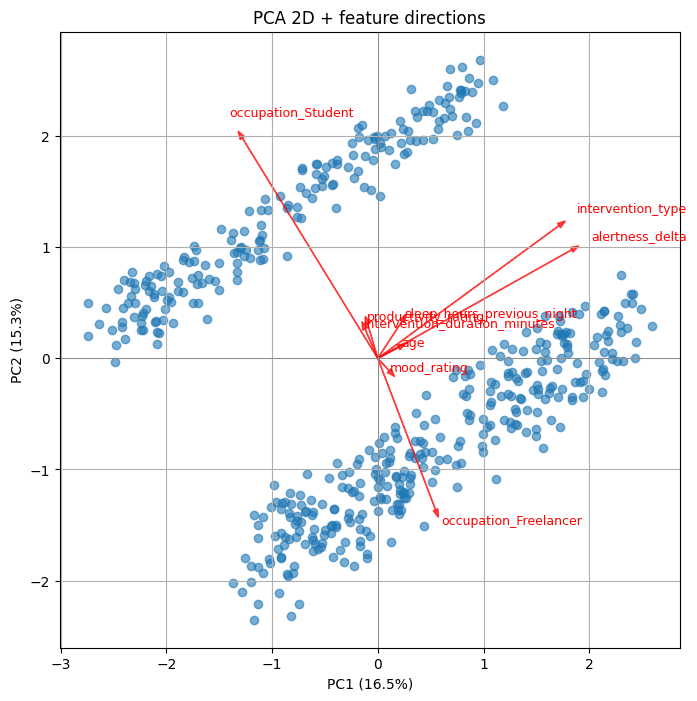

In [16]:
# X: (n_samples, n_features), names list length n_features
Xs = scaler.fit_transform(X)

pcan = PCA(n_components=2)
X2 = pcan.fit_transform(Xs)

plt.figure(figsize=(8,8))
plt.scatter(X2[:,0], X2[:,1], alpha=0.6)

arrow_scale = 3  # tune
for i, feat in enumerate(feature_names):
    x, y = pcan.components_[0, i], pcan.components_[1, i]
    plt.arrow(0, 0, x*arrow_scale, y*arrow_scale,
              color='red', alpha=0.7, width=0.002, head_width=0.05)
    plt.text(x*arrow_scale*1.1, y*arrow_scale*1.1, feat,
             color='red', fontsize=9)

plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.xlabel('PC1 (%.1f%%)' % (pcan.explained_variance_ratio_[0]*100))
plt.ylabel('PC2 (%.1f%%)' % (pcan.explained_variance_ratio_[1]*100))
plt.title('PCA 2D + feature directions')
plt.grid(True)
plt.show()

Quindi, sembra che i due cluster siano in grande parte determinati dall'essere uno studente o un freelancer

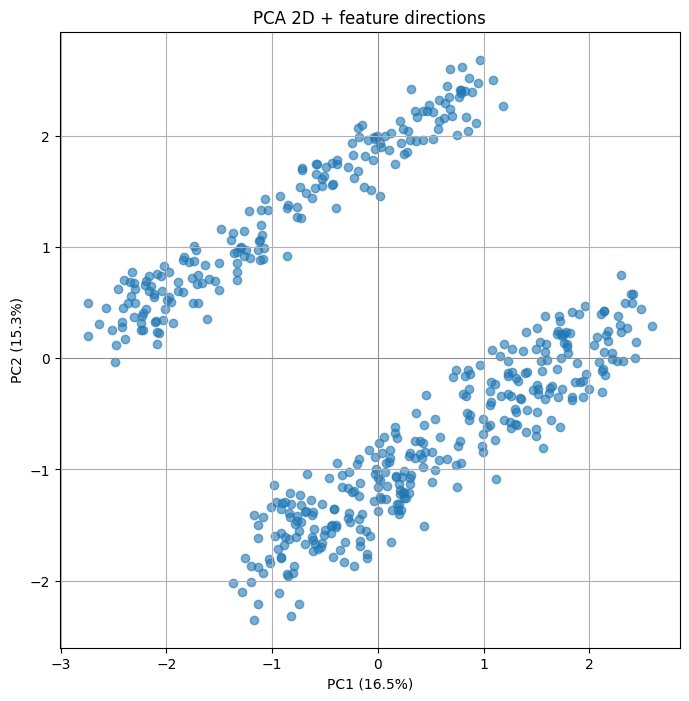

In [17]:
# X: (n_samples, n_features), names list length n_features
Xs = scaler.fit_transform(X)

pcan = PCA(n_components=2)
X2 = pcan.fit_transform(Xs)

plt.figure(figsize=(8,8))
plt.scatter(X2[:,0], X2[:,1], alpha=0.6)

arrow_scale = 3  # tune
for i, feat in enumerate(feature_names):
    if feat == "occupation_Working Professional":
        x, y = pcan.components_[0, i], pcan.components_[1, i]
        plt.arrow(0, 0, x*arrow_scale, y*arrow_scale,
                  color='red', alpha=0.7, width=0.002, head_width=0.05)
        plt.text(x*arrow_scale*1.1, y*arrow_scale*1.1, feat,
                 color='red', fontsize=9)

plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.xlabel('PC1 (%.1f%%)' % (pcan.explained_variance_ratio_[0]*100))
plt.ylabel('PC2 (%.1f%%)' % (pcan.explained_variance_ratio_[1]*100))
plt.title('PCA 2D + feature directions')
plt.grid(True)
plt.show()

Non so perché non compare la direzione relativa a occupation_Working professional : )

In [18]:
X_scaled["occupation_Working Professional"]

0      1.451065
1     -0.689149
2      1.451065
3     -0.689149
4      1.451065
         ...   
495   -0.689149
496   -0.689149
497   -0.689149
498    1.451065
499    1.451065
Name: occupation_Working Professional, Length: 500, dtype: float64

In definitiva, probabilmente questa analisi con PCA non ci dice molto, se non che i dati sono 6-7- dimensionali, e che le features più importanti per i primi due fattori sono l'alertness delta, il tipo di trattamento e le variabili relative all'occupazione.

Pertanto, almeno guardando solo le prime due componenti, potremmo preservare solo queste variabili senza perdere molte informazioni; questo però andrebbe verificato meglio, visto che le restanti variabili potrebbero essere importanti per i fattori 3,4,5,6.

Proviamo ora a fare un clustering k-means.

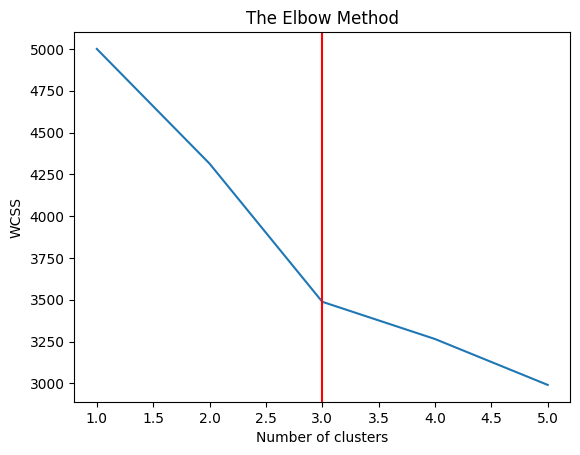

In [21]:
from sklearn.cluster import KMeans

wcss = [] # within cluster sum of squares
n_clusters = 5

for i in range(1, n_clusters+1):
    #Compute kmeans for different values of k. For instance, by varying k from 1 to 5 clusters
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42) # k-means++ is an algorithm for choosing a good initial centroids. 
    # For each k, calculate the total within-cluster sum of square (wss)
    kmeans.fit(X_scaled.to_numpy())
    wcss.append(kmeans.inertia_)
    
plt.plot(range(1, n_clusters+1), wcss)#, xticks=range(6)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.axvline(x=3, color='r', linestyle='-')
plt.show()

Sembra che, invece di 4 cluster associati ai side effects (None, Grogginess, Crash, Anxiety), la varianza spiegata suggerisca solo 3 clusters. Per completezza, proviamo a fare il clustering sia con 3 che con 4 clusters.

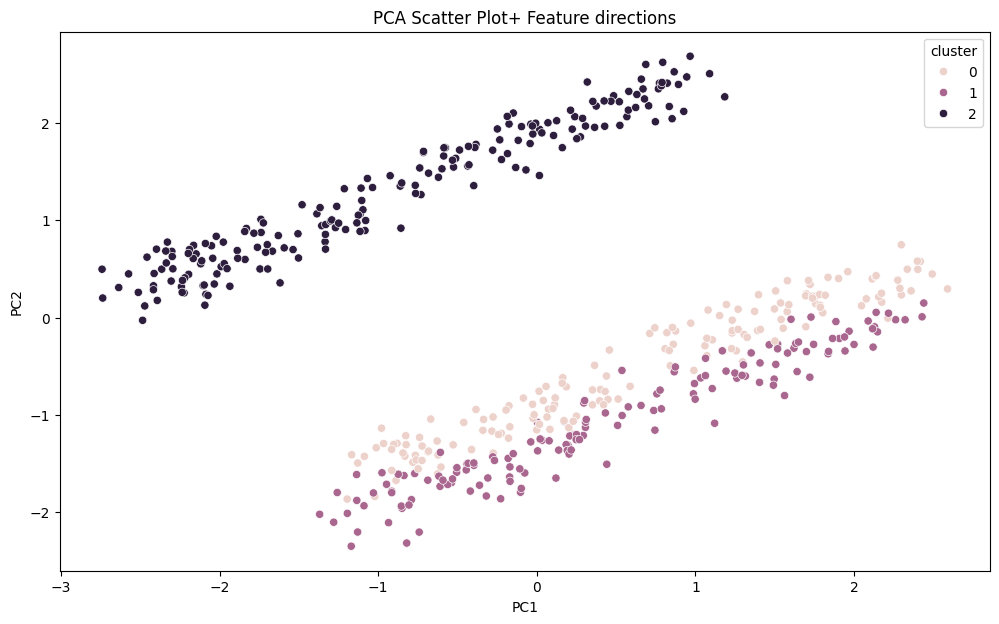

In [26]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++', random_state = 42)
kmeans.fit(X_scaled)
pc_df3 = pc_df.copy()
pc_df3['cluster'] = kmeans.labels_
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=pc_df3, x="PC1", y="PC2", hue="cluster" # Grouping data points with different colors
)

plt.title('PCA Scatter Plot+ Feature directions')
plt.show()

Il k-means con 3 cluster sembra recuperare il cluster in alto e dividere il cluster in basso in una fascia superiore ed una inferiore. 

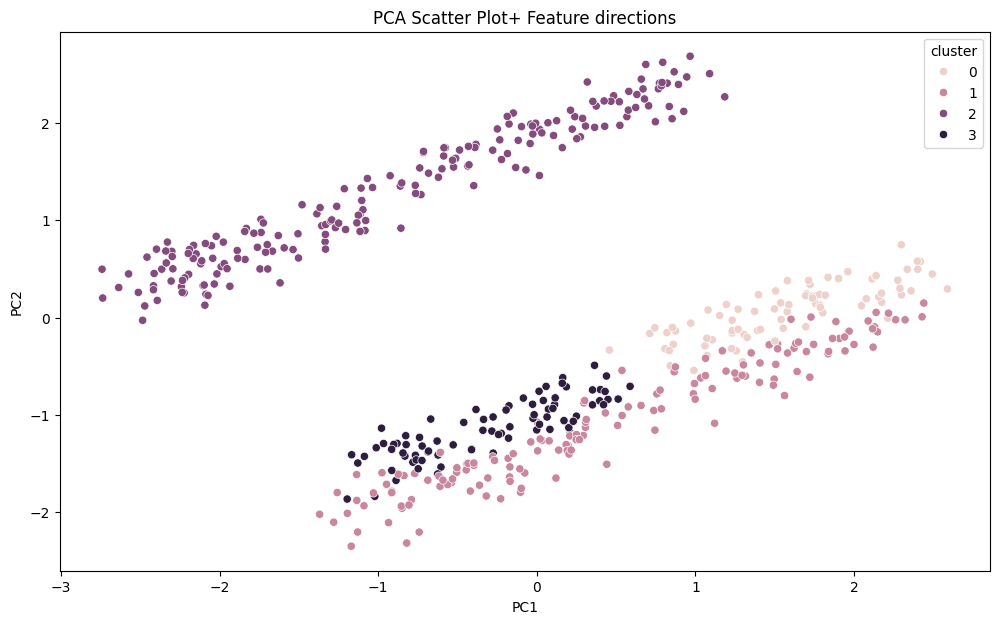

In [27]:
kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 42)
kmeans.fit(X_scaled)
pc_df3 = pc_df.copy()
pc_df3['cluster'] = kmeans.labels_
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=pc_df3, x="PC1", y="PC2", hue="cluster" # Grouping data points with different colors
)

plt.title('PCA Scatter Plot+ Feature directions')
plt.show()

Il k-means con 4 cluster prende la fascia superiore del gruppo in basso e la divide in 2, secondo la direzione corrispondente all'alertness delta ed all'intervention type.

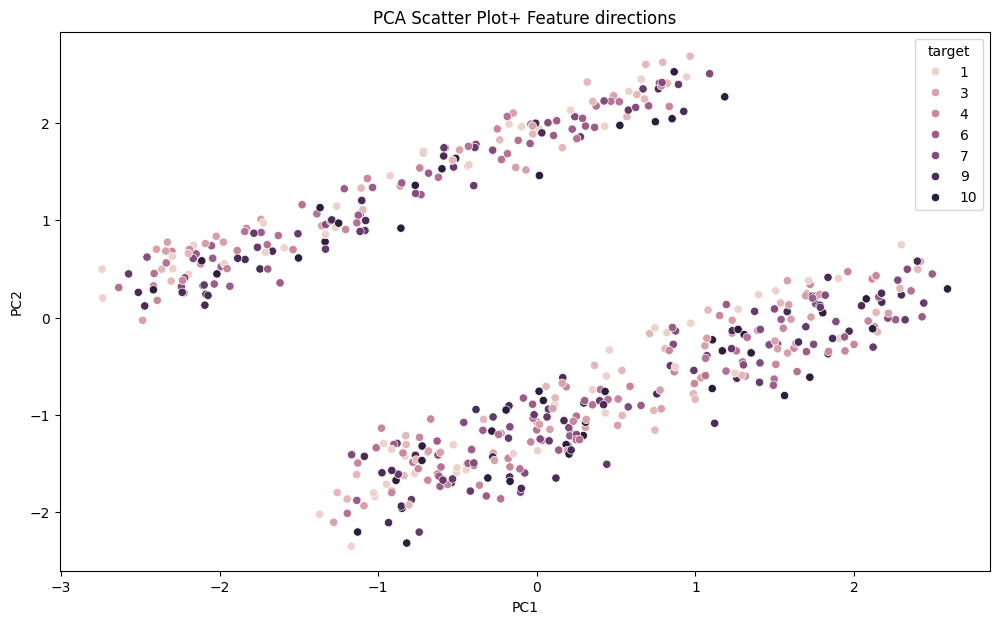

In [28]:
plt.figure(figsize=(12, 7))
pc_df["target"] = X.mood_rating
sns.scatterplot(
    data=pc_df, x="PC1", y="PC2", hue="target" # Grouping data points with different colors
)

plt.title('PCA Scatter Plot+ Feature directions')
plt.show()

Target: mood rating

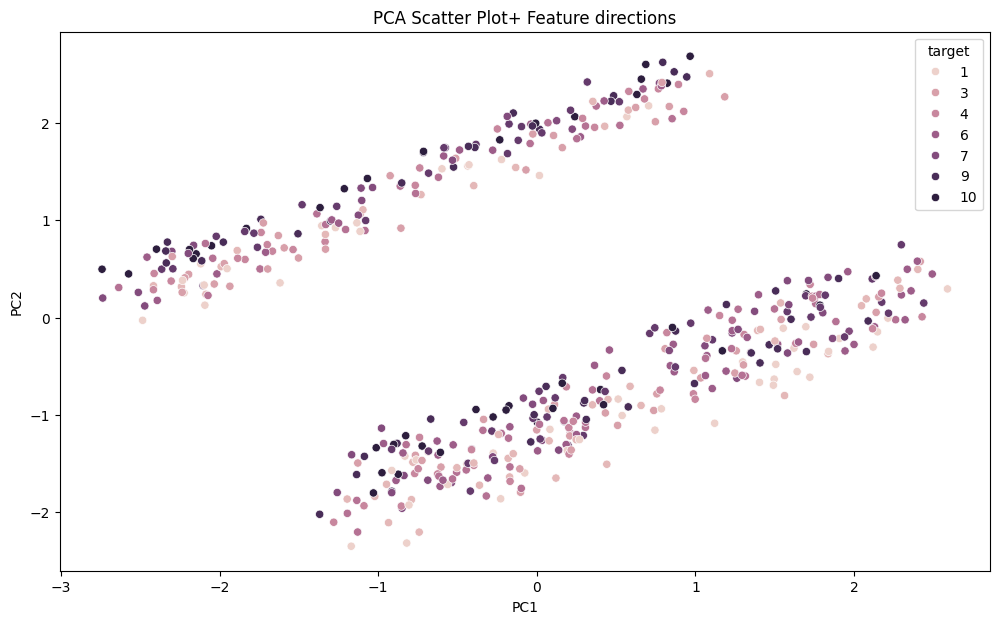

In [29]:
plt.figure(figsize=(12, 7))
pc_df["target"] = X["productivity_rating"]
sns.scatterplot(
    data=pc_df, x="PC1", y="PC2", hue="target" # Grouping data points with different colors
)

plt.title('PCA Scatter Plot+ Feature directions')
plt.show()

Productivity rating

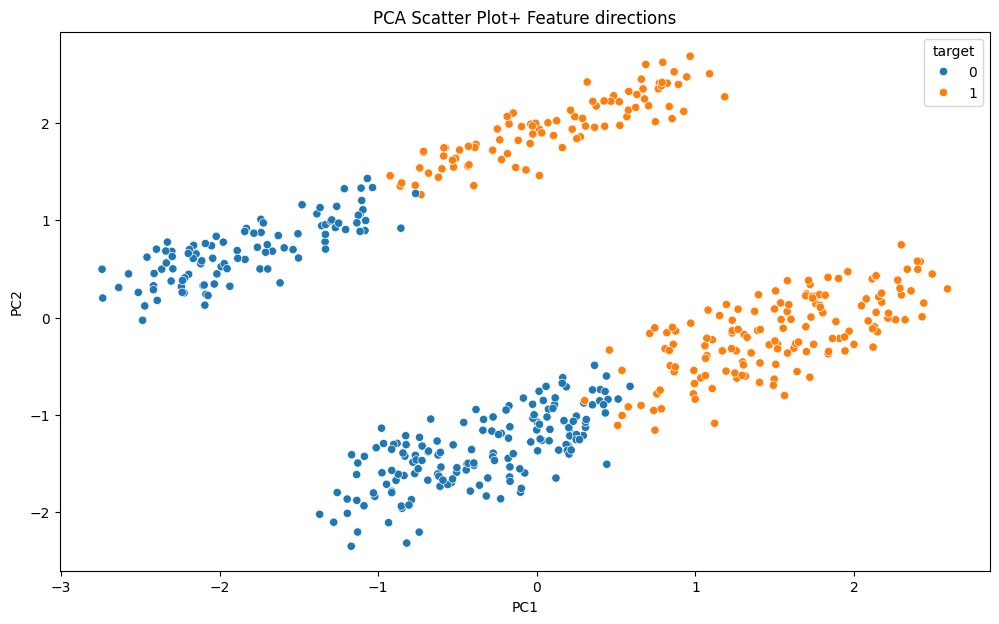

In [30]:
plt.figure(figsize=(12, 7))
pc_df["target"] = X["intervention_type"]
sns.scatterplot(
    data=pc_df, x="PC1", y="PC2", hue="target" # Grouping data points with different colors
)

plt.title('PCA Scatter Plot+ Feature directions')
plt.show()

Target: intervention type

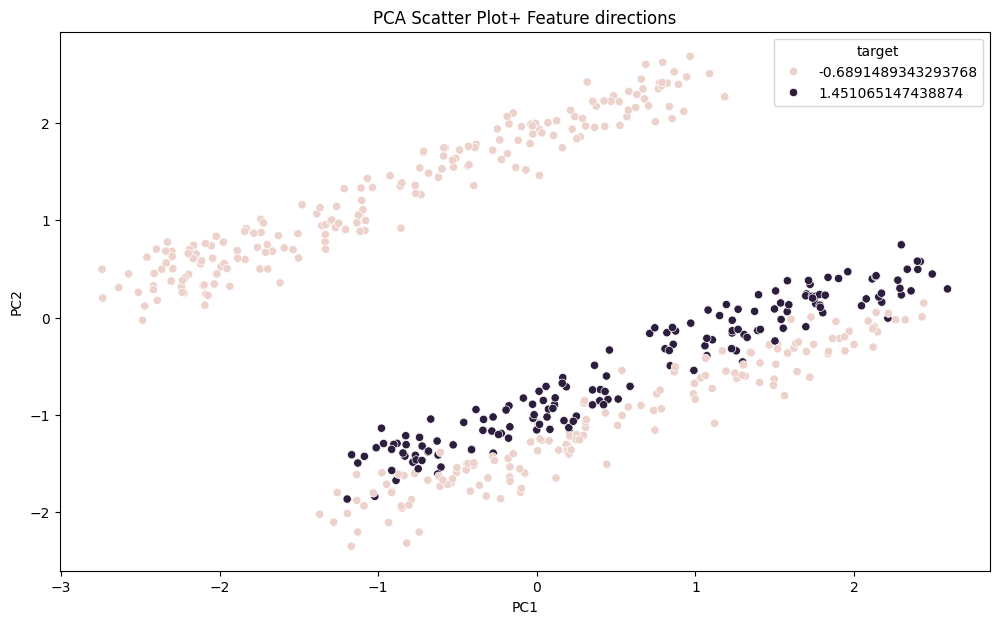

In [33]:
pc_df2["target"] = X_scaled["occupation_Working Professional"]
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=pc_df2, x="PC1", y="PC2", hue="target" # Grouping data points with different colors
)

plt.title('PCA Scatter Plot+ Feature directions')
plt.show()

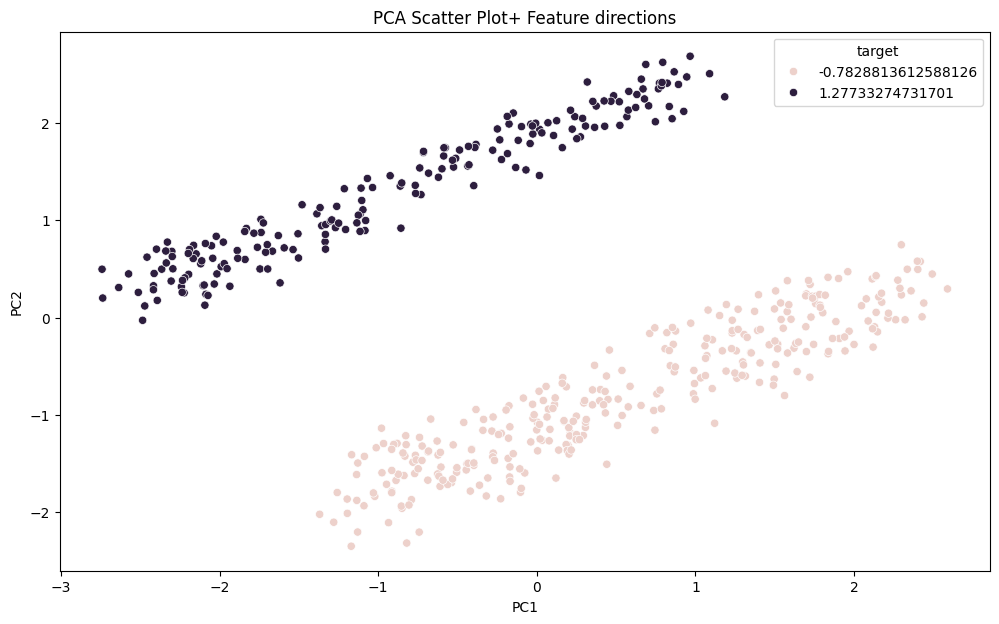

In [34]:
pc_df2["target"] = X_scaled["occupation_Student"]
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=pc_df2, x="PC1", y="PC2", hue="target" # Grouping data points with different colors
)

plt.title('PCA Scatter Plot+ Feature directions')
plt.show()

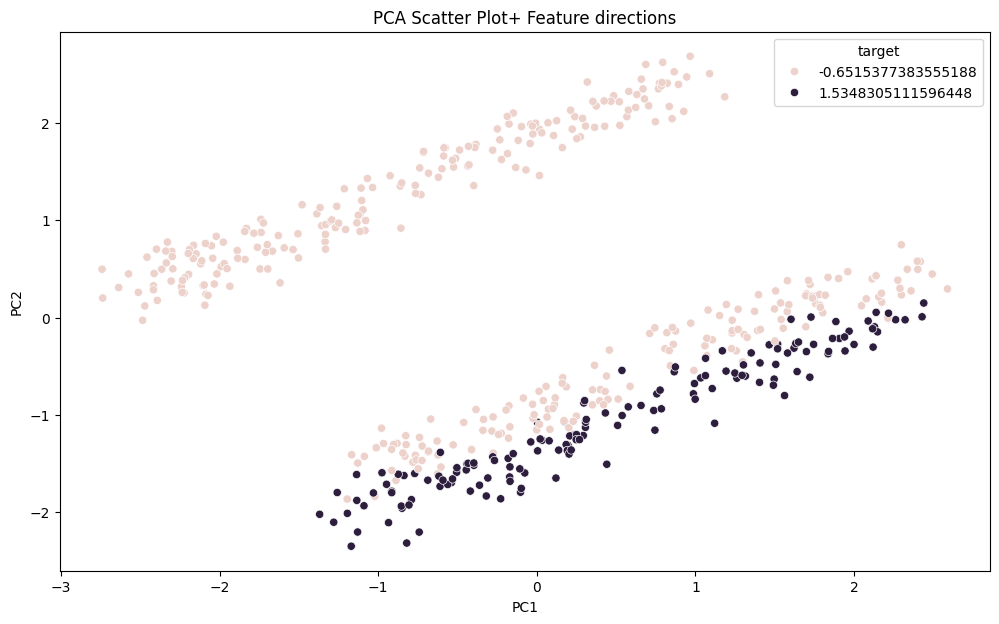

In [36]:
pc_df2["target"] = X_scaled["occupation_Freelancer"]
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=pc_df2, x="PC1", y="PC2", hue="target" # Grouping data points with different colors
)

plt.title('PCA Scatter Plot+ Feature directions')
plt.show()

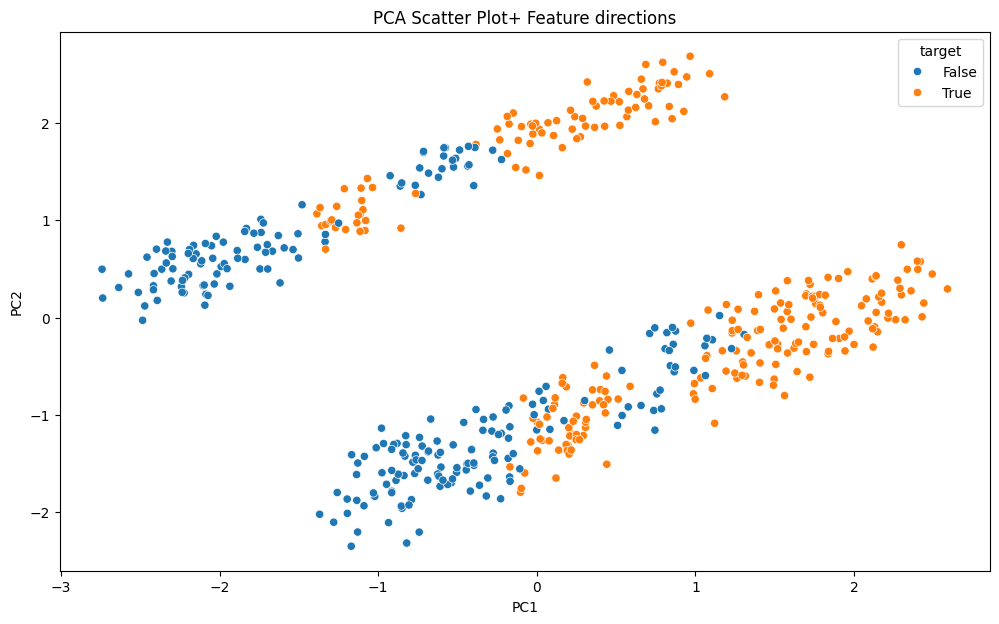

In [39]:
pc_df2["target"] = X_scaled["alertness_delta"]>0
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=pc_df2, x="PC1", y="PC2", hue="target" # Grouping data points with different colors
)

plt.title('PCA Scatter Plot+ Feature directions')
plt.show()

Quindi, i tre cluster trovati con k-means con k=3 corrispondono ai cluster degli studenti, dei lavoratori e dei freelancer. 
Quelli con k=4 corrispondono più o meno ai cluster degli studenti, e dei lavoratori dove quello dei lavoratori viene diviso in base all'intervention type (power nap per la direzione verso l'alto e caffè per quella verso il basso).

In definitiva, anche l'analisi tramite k-means non è granché conclusiva, visto che non riesce a spiegare di per sé la variabile relativa ai side effects. Questo però non è strano, visto che stiamo usando metodi unserpervised.

N.B.: Ho effettuato il clustering con i dati scalati, visto che questi sono disomogenei.

# TODO: Fare PCA e visualizzare clustering in 3D per componenti 1-2-3 e 4-5-6